In [2]:
import importlib
import miaw
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score


## Usage

In [3]:
# train-test data
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(56000, 784) (56000, 10) (14000, 784) (14000, 10)


In [4]:
# Random test sample from Kaggle
test_url = 'https://drive.google.com/uc?id=1VwGTcs1guwJTnUHKdOkMgDUtuW18DbEp'
test_df = pd.read_csv(test_url)

y_test = test_df["label"].values 
X_test = test_df.drop(columns=["label"]).values
print(X_test.shape, y_test.shape)

(10000, 784) (10000,)


## Pengaruh Depth dan Width

### Pengaruh Depth

In [ ]:
# Depth 0: No hidden layer
d0_model = FFNN([784,10], ['softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')
d0_history = d0_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 89.30%, Test accuracy: 91.24%


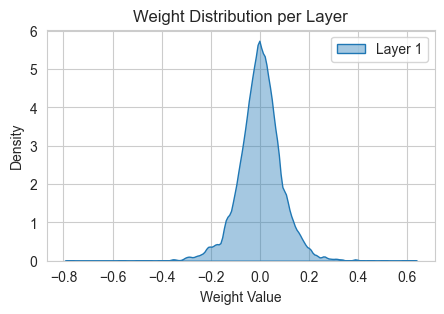

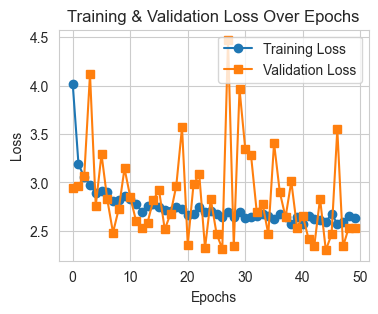

In [30]:
d0_test_pred = d0_model.predict(X_test)
d0_val_pred = d0_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(d0_val_pred, y_val_decoded)
test_accuracy = accuracy_score(d0_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

d0_model.plot_weight_distribution([0])
d0_model.plot_loss_history(d0_history)

In [ ]:
# Depth 1: 1 hidden layer
d1_model = FFNN([784, 64, 10], ['relu', 'softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')
d1_history = d1_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 93.28%, Test accuracy: 95.28%


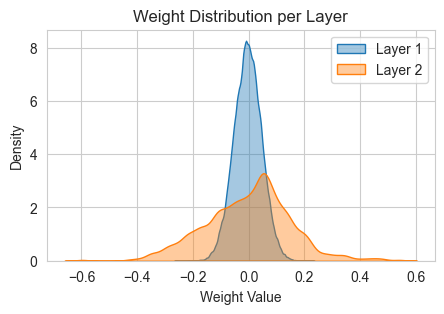

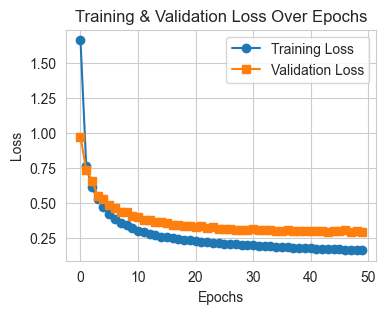

In [31]:
d1_test_pred = d1_model.predict(X_test)
d1_val_pred = d1_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(d1_val_pred, y_val_decoded)
test_accuracy = accuracy_score(d1_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

d1_model.plot_weight_distribution([0, 1])
d1_model.plot_loss_history(d1_history)

In [23]:
# Depth 2: 2 hidden layer
d2_model = FFNN([784, 64, 64, 10], ['relu', 'relu', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

d2_history = d2_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

In [ ]:
d2_test_pred = d2_model.predict(X_test)
d2_val_pred = d2_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(d2_val_pred, y_val_decoded)
test_accuracy = accuracy_score(d2_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

d2_model.plot_weight_distribution([0, 1, 2])
d2_model.plot_loss_history(d2_history)

Val accuracy: 92.73%, Test accuracy: 94.87%


In [28]:
d0_model.save('./models/depth0.json')
d1_model.save('./models/depth1.json')
d2_model.save('./models/depth2.json')

In [29]:
d0_model = FFNN.load('./models/depth0.json')

d0_test_pred = d0_model.predict(X_test)
d0_val_pred = d0_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(d0_val_pred, y_val_decoded)
test_accuracy = accuracy_score(d0_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")



Val accuracy: 89.30%, Test accuracy: 91.24%


In [ ]:
print(history)

{'train_loss': [np.float64(1.6052547209287529), np.float64(0.6521147537023916), np.float64(0.5087713568116594), np.float64(0.43336590395395147), np.float64(0.3822180108446402), np.float64(0.3419250360891706), np.float64(0.313131762119023), np.float64(0.28954895081082743), np.float64(0.27112823156536486), np.float64(0.2563747370129571)], 'val_loss': [np.float64(0.8099198351443412), np.float64(0.6028494769918604), np.float64(0.5066712613400949), np.float64(0.45018421904564204), np.float64(0.42036082997223595), np.float64(0.3819821919771226), np.float64(0.3721066421789023), np.float64(0.3621413159336413), np.float64(0.34134236263807655), np.float64(0.3267279016964207)]}
